In [ ]:
!pip install -q segmentation-models-pytorch opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.5 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.datasets import VOCSegmentation
from torchvision import transforms
import segmentation_models_pytorch as smp
from tqdm import tqdm

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
IMAGE_SIZE = 256
BATCH_SIZE = 4
NUM_CLASSES = 21

In [ ]:
img_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE),
                      interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor()
])

In [ ]:
class VOCDataset(torch.utils.data.Dataset):
    def __init__(self, split):
        self.dataset = VOCSegmentation(
            root="data",
            year="2012",
            image_set=split,
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]

        img = img_transform(img)
        mask = mask_transform(mask).long().squeeze()

        # Remove the problematic line that replaces ignore label 255 -> 0
        # mask[mask == 255] = 0

        return img, mask

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=255)

In [ ]:
train_ds = VOCDataset("train")
val_ds = VOCDataset("val")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

100%|██████████| 2.00G/2.00G [05:55<00:00, 5.62MB/s]


In [ ]:
def mean_iou(pred, target, num_classes=NUM_CLASSES):
    pred = pred.view(-1)
    target = target.view(-1)
    ious = []

    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union > 0:
            ious.append(intersection / union)

    return sum(ious) / len(ious)

In [ ]:
def train_model(model, optimizer, loss_fn, epochs=5):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for imgs, masks in tqdm(train_loader):
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss/len(train_loader):.4f}")

In [ ]:
def evaluate_model(model):
    model.eval()
    total_iou = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            total_iou += mean_iou(preds, masks)

    return total_iou / len(val_loader)

In [ ]:
unet = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    classes=NUM_CLASSES,
    activation=None
).to(device)

# Pass ignore_index=255 to DiceLoss to correctly ignore the 255 label
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=255)
optimizer = torch.optim.Adam(unet.parameters(), lr=1e-4)

print("Training U-Net...")
train_model(unet, optimizer, loss_fn, epochs=5)

unet_iou = evaluate_model(unet)
print("U-Net mIoU:", unet_iou)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Training U-Net...


100%|██████████| 366/366 [00:33<00:00, 10.85it/s]


...

Epoch [3/5] Loss: 0.8763


100%|██████████| 366/366 [00:34<00:00, 10.65it/s]


Epoch [4/5] Loss: 0.7975


100%|██████████| 366/366 [00:34<00:00, 10.63it/s]


Epoch [5/5] Loss: 0.7249
U-Net mIoU: 0.16671574553419008


In [ ]:
deeplab = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    classes=NUM_CLASSES,
    activation=None
).to(device)

optimizer = torch.optim.Adam(deeplab.parameters(), lr=1e-4)

print("Training DeepLabV3+...")
train_model(deeplab, optimizer, loss_fn, epochs=5)

deeplab_iou = evaluate_model(deeplab)
print("DeepLabV3+ mIoU:", deeplab_iou)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Training DeepLabV3+...


100%|██████████| 366/366 [00:47<00:00,  7.67it/s]


Epoch [1/5] Loss: 1.3898


...

Epoch [3/5] Loss: 0.5121


100%|██████████| 366/366 [00:46<00:00,  7.92it/s]


Epoch [4/5] Loss: 0.4015


100%|██████████| 366/366 [00:46<00:00,  7.88it/s]


Epoch [5/5] Loss: 0.3464
DeepLabV3+ mIoU: 0.34628361359608306


In [ ]:
segformer = smp.Segformer(
    encoder_name="mit_b2",
    encoder_weights="imagenet",
    classes=NUM_CLASSES,
    activation=None
).to(device)

optimizer = torch.optim.Adam(segformer.parameters(), lr=1e-4)

print("Training SegFormer...")
train_model(segformer, optimizer, loss_fn, epochs=5)

segformer_iou = evaluate_model(segformer)
print("SegFormer mIoU:", segformer_iou)

config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

Training SegFormer...


100%|██████████| 366/366 [00:52<00:00,  6.92it/s]


Epoch [1/5] Loss: 0.9572


...

Epoch [3/5] Loss: 0.2167


100%|██████████| 366/366 [00:49<00:00,  7.39it/s]


Epoch [4/5] Loss: 0.1612


100%|██████████| 366/366 [00:49<00:00,  7.41it/s]


Epoch [5/5] Loss: 0.1289
SegFormer mIoU: 0.49385181688651986


In [ ]:
def visualize(model):
    model.eval()
    img, mask = val_ds[0]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred = torch.argmax(pred, dim=1).squeeze().cpu()

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(img.permute(1,2,0))

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(mask)

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred)
    plt.show()

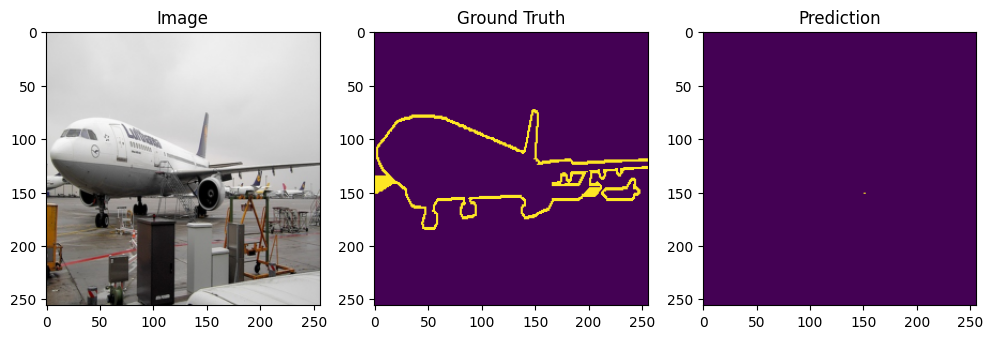

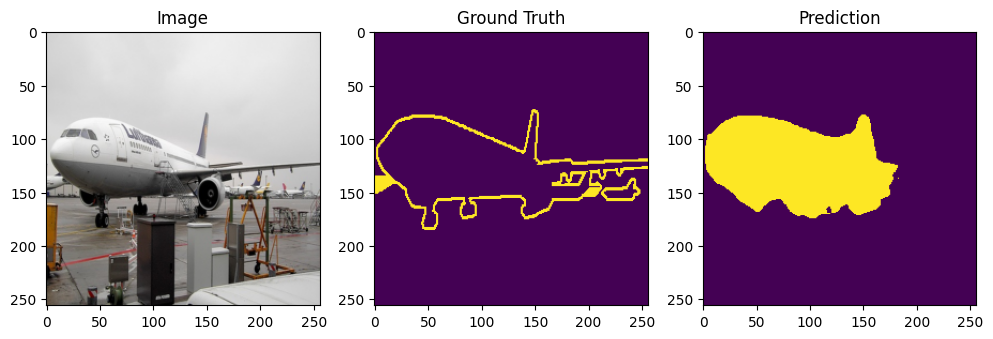

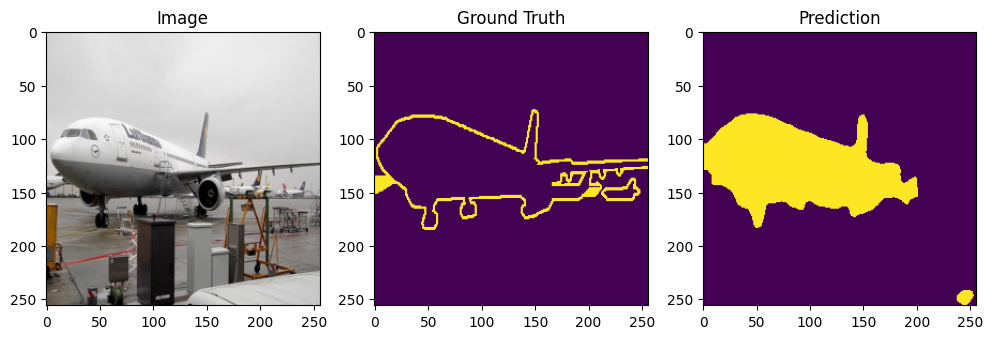

In [ ]:
visualize(unet)
visualize(deeplab)
visualize(segformer)